# Sendo a base apresentada no arquivo abaixo:
- https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce?select=olist_customers_dataset.csv
    - Já disponível no banco de dados `vendas_db.db` através do link:
        - https://drive.google.com/file/d/1eONzrbEu5BoijDRj56gjL_2Ik5qxtR6U/view?usp=sharing
<br><br>
- Sua tarefa é ajudar a área de negócios a **montar uma apresentação para a diretoria** para provar a **necessidade de investistimento em uma área de melhoria da experência do cliente ao ter um atraso na entrega**
<br><br>
- Algumas considerações são importantes
    - <font color='blue'>O **time de logística não considera que o atraso na entrega é um problema relevante** e falou que, em média, as entregas estão sendo feitas 10 dias antes do prazo combinado</font>
    - Não é desejado a previsão de uma entrega atrasada, apenas a **exposição que esse é um problema que pode impactar os clientes**
    - Não queremos uma abordagem de: "nenhuma entrega pode atrasar". Vamos ser mais tranquilos e seguir na linha de: **"uma entrega pode atrasar. Como eu posso melhorar a experiência do cliente caso isso aconteça?"**

### Preparando nosso "ambiente"

In [1]:
# Importando o sqlite3
import sqlite3

In [2]:
# Importando o pandas
import pandas as pd

In [3]:
# Criando uma conexão
con = sqlite3.connect('vendas_db.db')

In [4]:
# E então criando o cursor
cur = con.cursor()

In [5]:
# Usando a função python que já havíamos criado
def executa_consulta(consulta):
    resultado = cur.execute(consulta).fetchall()
    resultado = pd.DataFrame(resultado)
    colunas = [i[0] for i in cur.description]
    if resultado.shape[1] > 0:
        resultado.columns = colunas
    print(resultado.shape)
    display(resultado.head(3))
    return resultado

In [6]:
executa_consulta('SELECT * FROM sqlite_schema WHERE type = "table"')

(9, 5)


,type,name,tbl_name,rootpage,sql
0,table,sellers,sellers,2,"CREATE TABLE ""sellers"" (\n""index"" INTEGER,\n ..."
1,table,product_category_name_translation,product_category_name_translation,59,"CREATE TABLE ""product_category_name_translatio..."
2,table,order_items,order_items,5077,"CREATE TABLE ""order_items"" (\n""index"" INTEGER,..."


,type,name,tbl_name,rootpage,sql
0,table,sellers,sellers,2,"CREATE TABLE ""sellers"" (\n""index"" INTEGER,\n ..."
1,table,product_category_name_translation,product_category_name_translation,59,"CREATE TABLE ""product_category_name_translatio..."
2,table,order_items,order_items,5077,"CREATE TABLE ""order_items"" (\n""index"" INTEGER,..."
3,table,customers,customers,9612,"CREATE TABLE ""customers"" (\n""index"" INTEGER,\n..."
4,table,geolocation,geolocation,12254,"CREATE TABLE ""geolocation"" (\n""index"" INTEGER,..."
5,table,order_payments,order_payments,27180,"CREATE TABLE ""order_payments"" (\n""index"" INTEG..."
6,table,order_reviews,order_reviews,29199,"CREATE TABLE ""order_reviews"" (\n""index"" INTEGE..."
7,table,products,products,33274,"CREATE TABLE ""products"" (\n""index"" INTEGER,\n ..."
8,table,orders,orders,61,"CREATE TABLE ""orders"" (\n""index"" INTEGER,\n ""..."


### <font color='blue'> 1. O atraso é um problema real? </font>

In [7]:
# Podemos visualizar a tabela de pedidos
pedidos = executa_consulta('SELECT order_id, \
                           order_purchase_timestamp, \
                           order_delivered_customer_date, \
                           order_estimated_delivery_date \
                           FROM orders \
                           WHERE order_delivered_customer_date IS NOT NULL')

(96476, 4)


,order_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04 00:00:00


In [8]:
# Verificando as informações dessa base
pedidos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96476 entries, 0 to 96475
Data columns (total 4 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       96476 non-null  object
 1   order_purchase_timestamp       96476 non-null  object
 2   order_delivered_customer_date  96476 non-null  object
 3   order_estimated_delivery_date  96476 non-null  object
dtypes: object(4)
memory usage: 2.9+ MB


In [9]:
# Ajustando o tipo das colunas de data
lista_colunas = ['order_purchase_timestamp','order_delivered_customer_date','order_estimated_delivery_date']

for i in lista_colunas:
    pedidos[i] = pd.to_datetime(pedidos[i],format='%Y-%m-%d %H:%M:%S')

In [10]:
import datetime as dt

In [11]:
# Considerando apenas pedidos feitos após 2017
pedidos = pedidos[pedidos.order_purchase_timestamp.dt.year >= 2017]

In [12]:
# Calculando a diferença entre a data estimada e a data entregue
pedidos['atraso'] = (pedidos.order_estimated_delivery_date.dt.date - pedidos.order_delivered_customer_date.dt.date).dt.days

In [13]:
# Visualizando novamente a base
pedidos.head(3)

,order_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,atraso
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,8
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,6
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,18


In [14]:
# Verificando a média dos atrasos
pedidos.atraso.mean()

11.80772109267806

**Podemos verificar o mês que essa compra foi feita utilizando o `to_period`**
- https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.to_period.html

In [15]:
# Verificando o período (mês/ano) da compra
pedidos['mes'] = pedidos.order_purchase_timestamp.dt.to_period("M")

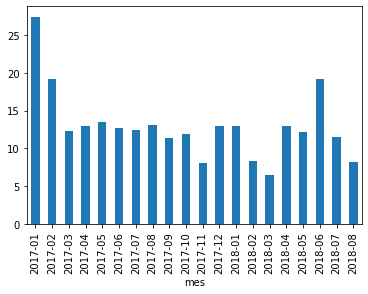

In [16]:
# Verificando o atraso por mês
pedidos.groupby('mes')['atraso'].mean().plot.bar();

**Realmente a média das entregas é de 10 dias, mas a média é um bom indicador?**

In [17]:
# Além da média, vamos analisar o máximo e o mínimo
media = pedidos.groupby('mes')['atraso'].mean()
minimo = pedidos.groupby('mes')['atraso'].min()
maximo = pedidos.groupby('mes')['atraso'].max()

In [18]:
import matplotlib.pyplot as plt
import numpy as np

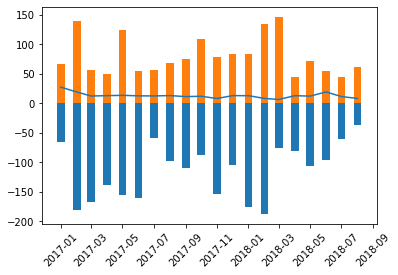

In [20]:
# Plotando graficamente
fig, ax = plt.subplots()

ax.plot(media.index.to_timestamp(), media.values)
ax.bar(minimo.index.to_timestamp(), minimo.values,width=15)
ax.bar(maximo.index.to_timestamp(), maximo.values,width=15)

plt.xticks(rotation=45)

plt.show()

**E se analisarmos a quantidade de pedidos com atraso?**

In [21]:
# Criando uma marcação para verificar se o pedido atrasou ou não
pedidos['flag_atraso'] = pedidos.atraso.apply(lambda x: 1 if x < 0 else 0)

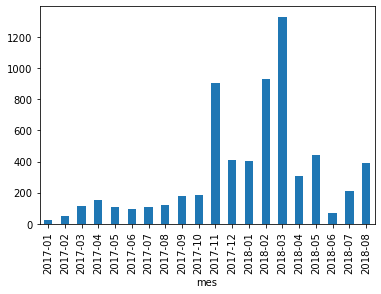

In [33]:
# E contando, mensalmente, quantos pedidos atrasaram
pedidos.groupby('mes')['flag_atraso'].sum().plot.bar();

In [34]:
# Analisando a relação entre o número de pedidos feitos e atrasados
pedidos_atrasados = pedidos.groupby('mes')['flag_atraso'].sum()
contagem_pedidos = pedidos.groupby('mes')['flag_atraso'].count()

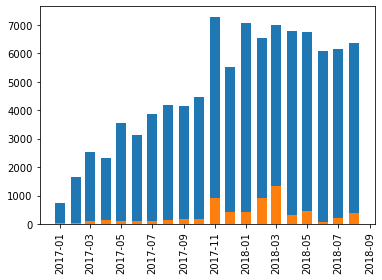

In [42]:
# Visualizando graficamente
fig, ax = plt.subplots()

ax.bar(contagem_pedidos.index.to_timestamp(), contagem_pedidos.values,width=20)
ax.bar(pedidos_atrasados.index.to_timestamp(), pedidos_atrasados.values,width=20)

plt.xticks(rotation=90)

plt.show()

In [44]:
(pedidos_atrasados/contagem_pedidos)*100

mes
2017-01     2.933333
2017-02     2.964307
2017-03     4.556167
2017-04     6.556665
2017-05     2.990127
2017-06     3.030303
2017-07     2.789256
2017-08     2.909611
2017-09     4.385542
2017-10     4.175971
2017-11    12.403952
2017-12     7.455106
2018-01     5.700948
2018-02    14.139719
2018-03    18.963301
2018-04     4.501324
2018-05     6.563935
2018-06     1.164698
2018-07     3.378817
2018-08     6.188002
Freq: M, Name: flag_atraso, dtype: float64

In [49]:
pedidos_atraso = pedidos_atrasados
contagem = contagem_pedidos
percentual = round((pedidos_atrasados/contagem_pedidos)*100,1)

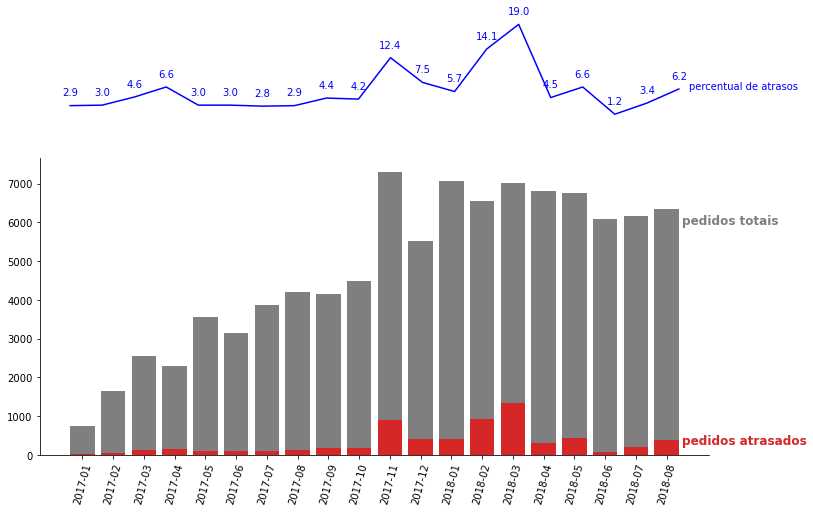

In [50]:
# Melhorando a visualização
fig, ax = plt.subplots(nrows=2,figsize=(12,8),gridspec_kw={'height_ratios': [1,3]})

x = np.arange(0,len(contagem))

ax[1].bar(x, contagem.values, linewidth=2.0,color='tab:gray')
ax[1].bar(x, pedidos_atraso.values, linewidth=2.0,color='tab:red')
ax[0].plot(x,percentual.values,c='b')

ax[0].xaxis.set_visible(False)
ax[0].yaxis.set_visible(False)
for i in x:
    ax[0].annotate(percentual.values[i],(i,percentual.values[i]),ha="center",xytext=(0,10),textcoords="offset points",c='b')
ax[0].spines['top'].set_visible(False)
ax[0].spines['left'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].spines['bottom'].set_visible(False)
ax[0].annotate('percentual de atrasos',(x[-1],percentual.values[-1]),ha="left",xytext=(10,0),textcoords="offset points",c='b')
    
ax[1].set_xticks(x)
ax[1].set_xticklabels(contagem.index,rotation=75)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].annotate('pedidos totais',(x[-1],contagem.values[-1]),ha="left",xytext=(15,-15),
               textcoords="offset points",c='tab:gray',fontsize=12,fontweight='bold')
ax[1].annotate('pedidos atrasados',(x[-1],pedidos_atraso.values[-1]),ha="left",xytext=(15,-5),
               textcoords="offset points",c='tab:red',fontsize=12,fontweight='bold')

plt.savefig('pedidos_atrasados',transparent=True)